In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astroML import stats as astroMLstats
import scipy.stats as stats
from scipy.stats import norm
from scipy.stats import uniform
import scipy.stats
from scipy import optimize

# The physics of Black Hole irreducible mass

The irreducible mass ($M_{\text{irr}}$) is a fundamental concept in black hole thermodynamics. 

For a Kerr (rotating) black hole with total mass $M$ and dimensionless spin $\chi$ (where $0 \le \chi \le 1$), the irreducible mass is defined as:

$$M_{\text{irr}} = M \sqrt{\frac{1 + \sqrt{1 - \chi^2}}{2}} = M \cdot f(\chi)$$

Physically, $M_{\text{irr}}$ represents the mass of a black hole that cannot be removed via the Penrose process. While a black hole can lose rotational energy (decreasing its total mass $M$), its surface area and thus its irreducible mass can never decrease ($dA \ge 0$)


## Tasks:


Assume a population of black holes where:
* The total mass $M$ is measured with some Gaussian uncertainty: $M \sim \mathcal{N}(\mu, \sigma)$;
* The spin $\chi$ is distributed uniformly: $\chi \sim U(0, 1)$.The factor $f(\chi)$ acts as a "compression" term. Because $\chi$ is between 0 and 1, the factor $f$ varies between $1/\sqrt{2} \approx 0.707$ (for a maximally rotating BH) and $1.0$ (for a non-rotating BH);
* Masses and spins are uncorrelated.

1. Start with a value of $\sigma = 0.02$. Note that $\mu$ is a scale and not a parameter: you can normalize all quantities with a dimension of mass by $\mu$. Just set $\mu = 1$ in your code and remember that all masses in the problem are measured in units of $\mu$.

2. Plot the resulting pdf of $M_{irr}$. First try an histogram with one the rules of thumb we've seen above.

Hint (for point 2): You don't know the functional form of the pdf of $M_{irr}$... but you don't need it if you just want to generate samples! That's the nice thing about numerics!



In [2]:
mu = 1
sigma = 0.02
N=100000
spin = np.random.uniform(0,1,N)
M = np.random.normal(mu,sigma, N)

In [3]:
irr_M_sample = M*np.sqrt((1+np.sqrt(1-spin**2))/2)

Text(0.5, 0, '$M_{irr}$ [$\\mu$]')

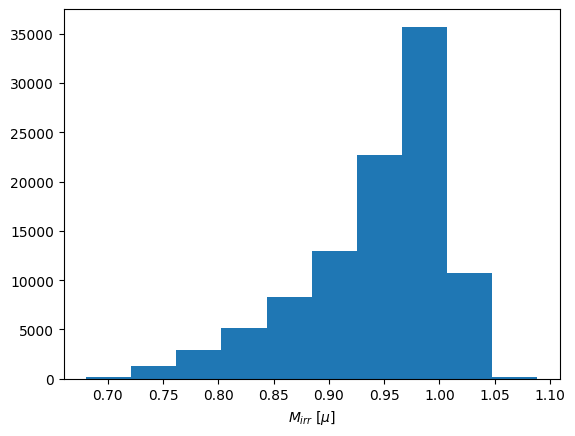

In [4]:
plt.hist(irr_M_sample)
plt.xlabel(r'$M_{irr}$ [$\mu$]')

In [5]:
def scott_rule_histo(data):
    bin_width = 3.5*np.std(data)/len(data)**(1/3)
    bins = np.append(np.arange(start=data.min(), stop=data.max(), step=bin_width) , data.max())  # Create edges
    print(f"Scott's bin width: {bin_width}")
    return bins

def FD_rule(data):
    sigmaG = astroMLstats.sigmaG(data)
    bin_width = 2.7*sigmaG/(N**(1/3))
    binsG = np.append(np.arange(start=data.min(), stop=data.max(), step=bin_width) , data.max()) 
    print(f"F-D's bin width: {bin_width}")
    return binsG

Scott's bin width: 0.0048471945180758
F-D's bin width: 0.0034660678853728547


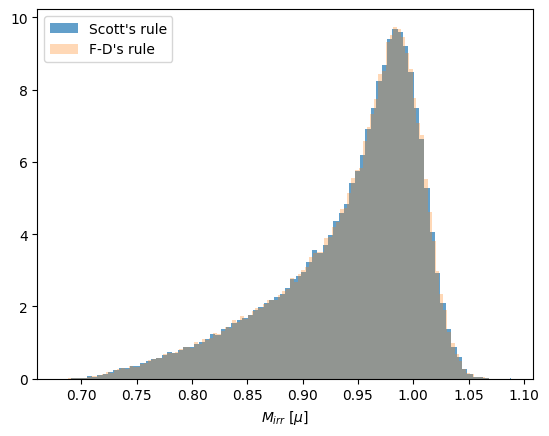

In [6]:
bins_scott = scott_rule_histo(irr_M_sample)
bins_FD = FD_rule(irr_M_sample)
plt.hist(irr_M_sample, bins=bins_scott, label ="Scott's rule", alpha=0.7, density='True')
plt.hist(irr_M_sample, bins=bins_FD, label ="F-D's rule", alpha=0.3, density='True')
plt.xlabel(r'$M_{irr}$ [$\mu$]')
plt.legend()

3. Using the same samples, plot the distribution of $M_{irr}$ using a KDE.

4. Compute the KS distance between $M_{irr}/\mu$ and $f$ as a function of $\sigma$. Discuss the limits at large and small values of $\sigma$.

5. Compute the KS distance between $M_{irr}$ and $M$ as a function of $\sigma$. Discuss the limits at large and small values of $\sigma$.

Hint (for points 4 and 5). This is a KS test between two sets for samples, scipy.stats.ks_2samp.

You should find that (i) $M_{irr}$ is distributed like $f$ if $\sigma<<\mu$ and (ii) $M_{irr}$ is distributed like $M$ if $\sigma>>\mu.$

In [7]:
from sklearn.neighbors import KernelDensity
datagrid = np.linspace(irr_M_sample.min(),irr_M_sample.max(),1000)

def kde_sklearn(data, datagrid, bandwidth = 1.0, kernel="linear"):
    kde_skl = KernelDensity(bandwidth = bandwidth, 
                            kernel=kernel)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(datagrid[:, np.newaxis]) # sklearn returns log(density)
    return np.exp(log_pdf)

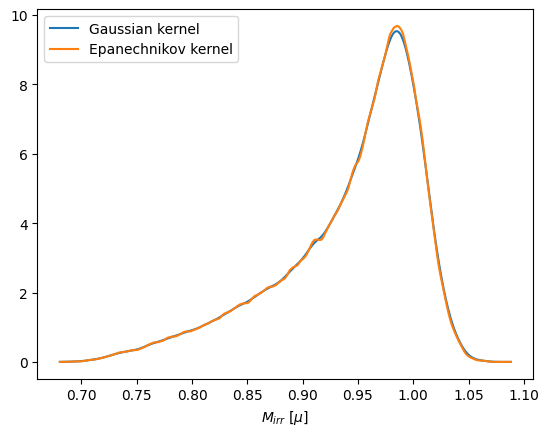

In [8]:

PDFgauss = kde_sklearn(irr_M_sample,datagrid,bandwidth=0.005,kernel="gaussian")
plt.plot(datagrid,PDFgauss, label='Gaussian kernel') 

PDFepa = kde_sklearn(irr_M_sample,datagrid,bandwidth=0.005,kernel="epanechnikov") 
plt.plot(datagrid,PDFepa, label='Epanechnikov kernel') 
plt.xlabel(r'$M_{irr}$ [$\mu$]')
plt.legend()

In [14]:
def KS_stats(sigma, N):
    mu =1
    spin = np.random.uniform(0,1,N)
    M = np.random.normal(mu,sigma, N)
    irr_M_sample = M*np.sqrt((1+np.sqrt(1-spin**2))/2)
    f_KS=stats.ks_2samp(irr_M_sample, np.sqrt((1+np.sqrt(1-spin**2))/2))
    M_KS =stats.ks_2samp(irr_M_sample, M)
    print(f"KS test for f: {f_KS}")
    return f_KS[0], M_KS[0]

In [15]:
f_KS=[]
M_KS=[]
sigma = np.logspace(-6,3, 20, endpoint='True')
for s in sigma:
    f, M = KS_stats(s, N)
    f_KS.append(f)
    M_KS.append(M)

KS test for f: KstestResult(statistic=np.float64(0.0011400000000000299), pvalue=np.float64(0.9999999378190719), statistic_location=np.float64(0.9999999999999607), statistic_sign=np.int8(-1))
KS test for f: KstestResult(statistic=np.float64(0.0023699999999999832), pvalue=np.float64(0.9408697491719401), statistic_location=np.float64(0.9999999999975714), statistic_sign=np.int8(-1))
KS test for f: KstestResult(statistic=np.float64(0.003489999999999993), pvalue=np.float64(0.5751235832755992), statistic_location=np.float64(0.9999999999803729), statistic_sign=np.int8(-1))
KS test for f: KstestResult(statistic=np.float64(0.005789999999999962), pvalue=np.float64(0.06972646771776825), statistic_location=np.float64(0.9999999999997599), statistic_sign=np.int8(-1))
KS test for f: KstestResult(statistic=np.float64(0.010210000000000052), pvalue=np.float64(5.898278927228813e-05), statistic_location=np.float64(0.9999999998487052), statistic_sign=np.int8(-1))
KS test for f: KstestResult(statistic=np.flo

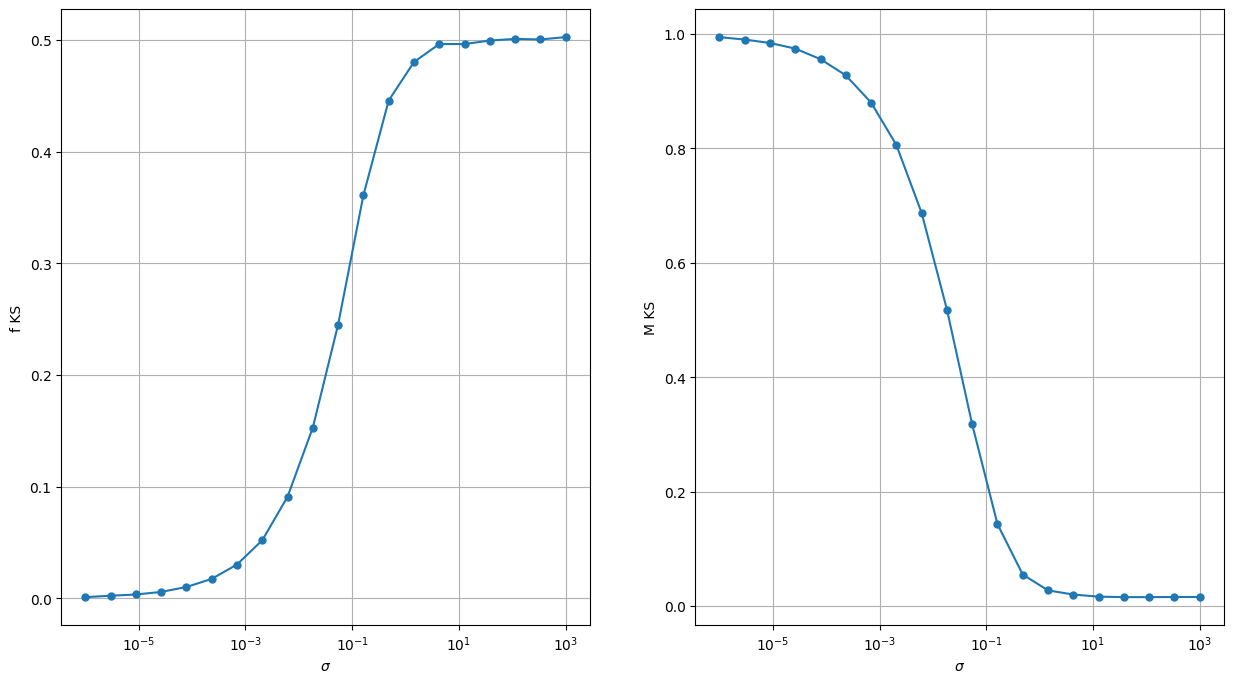

In [16]:
fig, ax =plt.subplots(1,2, figsize=(15,8))
ax[0].plot(sigma, f_KS, '.', ls='-', ms=10)
ax[1].plot(sigma, M_KS, '.', ls='-',ms=10)
ax[0].set_ylabel('f KS')
ax[1].set_ylabel('M KS')
for axi in ax:
    axi.set_xlabel(r'$\sigma$')
    
    axi.set_xscale('log')
    #axi.set_yscale('log')
    #axi.set_ylim(0,0.1)
    axi.grid()

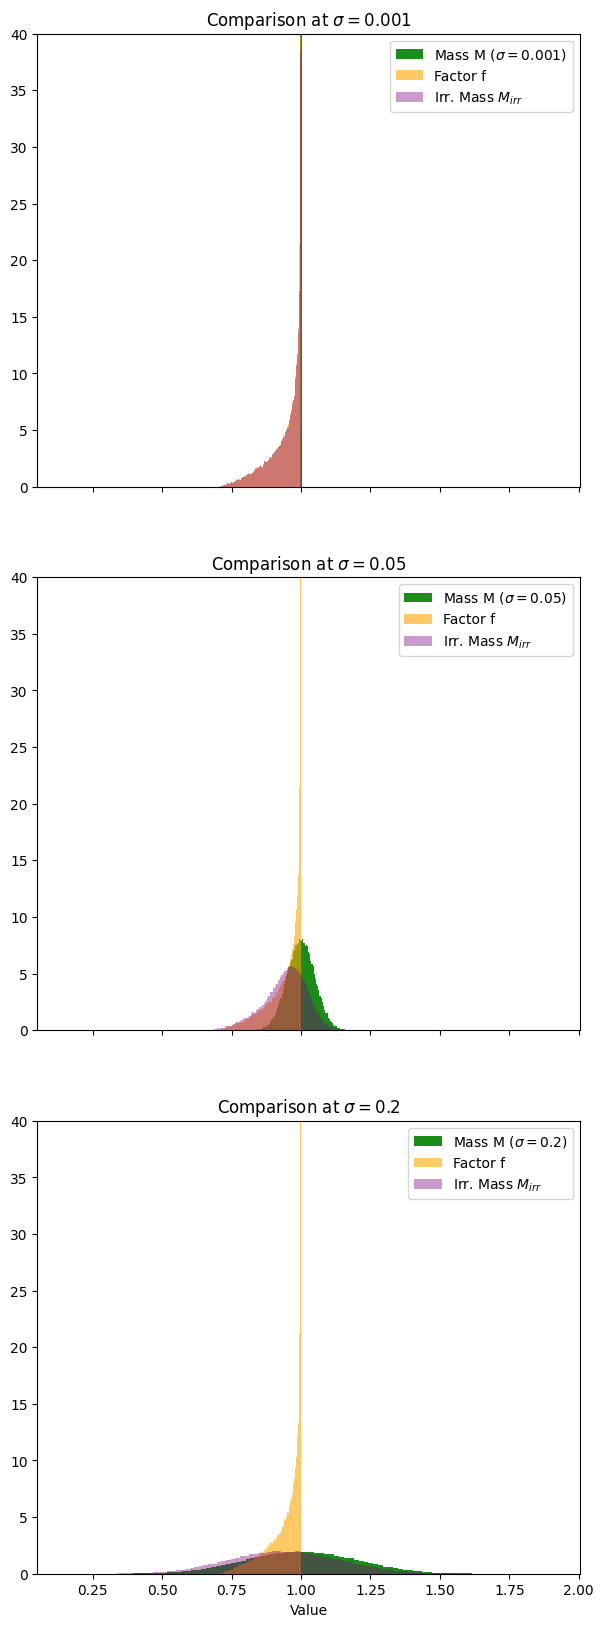

In [14]:
sigmas = [0.001, 0.05, 0.2]
fig_h, axes_h = plt.subplots(len(sigmas), 1, figsize=(7, 20), sharex=True)

for i, s in enumerate(sigmas):
    M_s = norm.rvs(loc=mu, scale=s, size=N)
    spin_s = uniform.rvs(loc=0, scale=1, size=N)
    f_samples = np.sqrt((1+np.sqrt(1-spin_s**2))/2)
    Mirr_s = M_s * f_samples
    
    axes_h[i].hist(M_s, bins=100, density=True, alpha=0.9, label=f'Mass M ($\sigma={s}$)', color='green')
    axes_h[i].hist(f_samples, bins=100, density=True, alpha=0.6, label='Factor f', color='orange')
    axes_h[i].hist(Mirr_s, bins=100, density=True, alpha=0.4, label='Irr. Mass $M_{irr}$', color='purple')
    axes_h[i].set_title(f"Comparison at $\sigma = {s}$")
    axes_h[i].legend()
    axes_h[i].set_ylim(0,40)

axes_h[-1].set_xlabel("Value")
#plt.tight_layout()
plt.show()

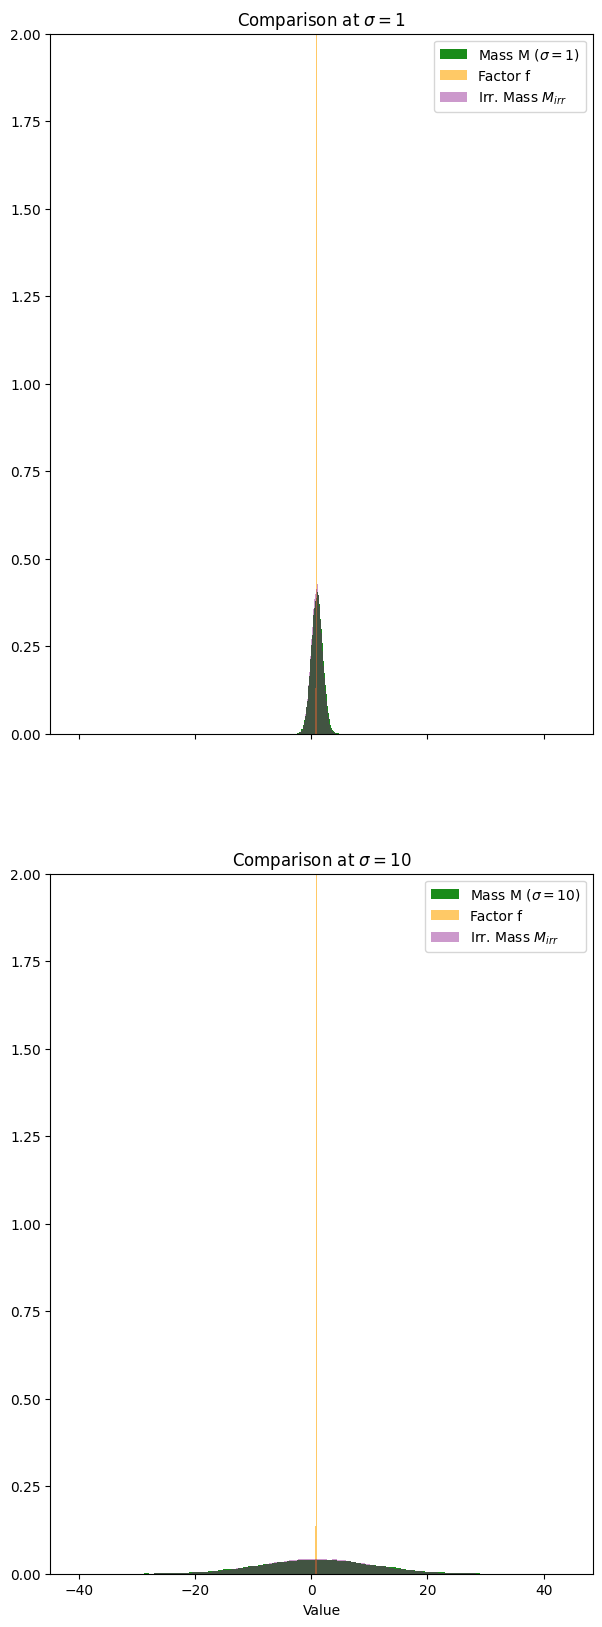

In [19]:
sigmas = [1, 10]
fig_h, axes_h = plt.subplots(len(sigmas), 1, figsize=(7, 20), sharex=True)

for i, s in enumerate(sigmas):
    M_s = norm.rvs(loc=mu, scale=s, size=N)
    spin_s = uniform.rvs(loc=0, scale=1, size=N)
    f_samples = np.sqrt((1+np.sqrt(1-spin_s**2))/2)
    Mirr_s = M_s * f_samples
    
    axes_h[i].hist(M_s, bins=100, density=True, alpha=0.9, label=f'Mass M ($\sigma={s}$)', color='green')
    axes_h[i].hist(f_samples, bins=100, density=True, alpha=0.6, label='Factor f', color='orange')
    axes_h[i].hist(Mirr_s, bins=100, density=True, alpha=0.4, label='Irr. Mass $M_{irr}$', color='purple')
    axes_h[i].set_title(f"Comparison at $\sigma = {s}$")
    axes_h[i].set_ylim(0,2)
    axes_h[i].legend()

axes_h[-1].set_xlabel("Value")
#plt.tight_layout()
plt.show()

6. Compute the pdf of f from its mathematical definition (pen and paper!).
 
$$f(\chi) = \sqrt{\frac{1 + \sqrt{1 - \chi^2}}{2}}$$

Assuming a uniform distribution for spin $\chi \sim U(0,1)$, the PDF of $f$ using the method of transformation of variables is:

$$p_f(f) = p_\chi(\chi) \left| \frac{d\chi}{df} \right|$$

By inverting the function to find $\chi(f)$ and calculating the Jacobian:

$$p_f(f) = \frac{4f^2 - 2}{\sqrt{1 - f^2}} \quad \text{for } f \in \left[\frac{1}{\sqrt{2}}, 1\right]$$
 
 

7. Compute the pdfs of $M_{irr}$ from its mathematical definition (pen and paper!).
 
Since $M_{\text{irr}}$ is the product of two independent random variables ($M$ and $f$), its PDF is calculated via a product convolution integral:

$$p_{M_{\text{irr}}}(m) = \int_{f_{min}}^{f_{max}} p_f(f) \, p_M\left(\frac{m}{f}\right) \frac{1}{f} \, df$$

Where $p_M$ is the Gaussian distribution $\mathcal{N}(\mu, \sigma)$. This integral accounts for how the measurement uncertainty in $M$ "smears" the underlying relativistic distribution of $f$.


8. Using the expressions from point 6 and 7, plot those pdfs check that they agree with your KDE reconstructions.

In [23]:
import scipy.stats as stats
from scipy.stats import norm, uniform
from sklearn.neighbors import KernelDensity
from scipy.integrate import quad



def pdf_f_analytic(f):
    """Analytic pdf for f(spin) for spin ~ U(0,1)"""
    mask = (f > 1/np.sqrt(2)) & (f < 1)
    res = np.zeros_like(f)
    res[mask] = (4*f[mask]**2 - 2) / np.sqrt(1 - f[mask]**2)
    return res

def pdf_Mirr_numerical(m, mu, sigma):
    """Numerical pdf for M_irr = M * f through product integral"""
    def integrand(f, m, mu, sigma):
        pf = (4*f**2 - 2) / np.sqrt(1 - f**2)
        pm = norm.pdf(m/f, loc=mu, scale=sigma)
        return pf * pm / f
    
    if np.isscalar(m):
        res, _ = quad(integrand, 1/np.sqrt(2), 1, args=(m, mu, sigma))
        return res
    else:
        return np.array([quad(integrand, 1/np.sqrt(2), 1, args=(val, mu, sigma))[0] for val in m])


In [31]:
mu, sigma_val, N = 1.0, 0.02, 100000
#Sampling
spin = np.random.uniform(0,1,N)
M = np.random.normal(mu,sigma_val, N)
f_samples = np.sqrt((1 + np.sqrt(1 - spin**2)) / 2)
Mirr_samples = M * f_samples

#Histo features
bins_scott_f = scott_rule_histo(f_samples)
bins_scott_M = scott_rule_histo(Mirr_samples)

#kde reconstruction
f_grid = np.linspace(1/np.sqrt(2) + 0.001, 1, 500)
Mirr_grid = np.linspace(min(Mirr_samples), max(Mirr_samples), 500)
f_kde = kde_sklearn(f_samples,f_grid, bandwidth=0.005,kernel="epanechnikov")
M_irr_kde = kde_sklearn(Mirr_samples,Mirr_grid,bandwidth=0.005,kernel="gaussian")


Scott's bin width: 0.0046619485837480846
Scott's bin width: 0.004870935877771159


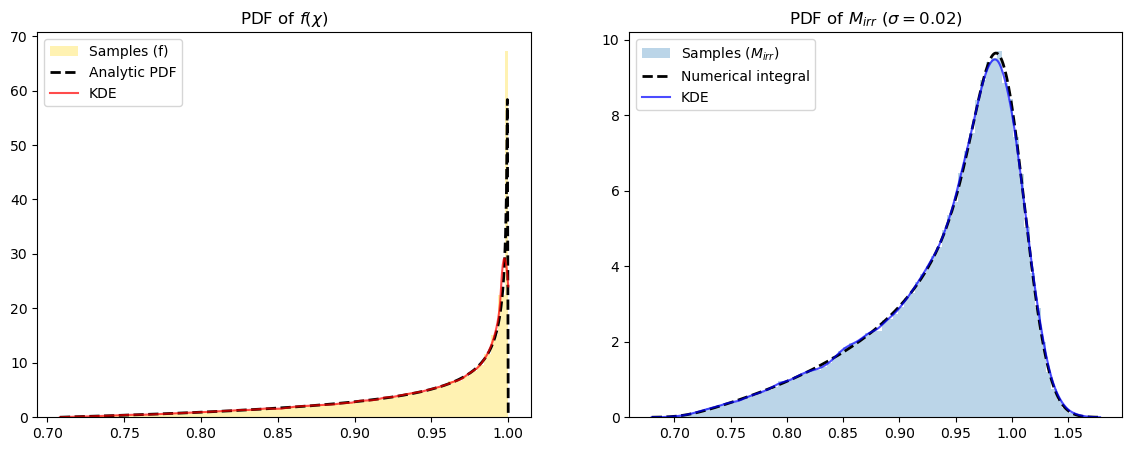

In [33]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))


ax[0].hist(f_samples, bins=bins_scott_f, density=True, alpha=0.3, label='Samples (f)', color='gold')
ax[0].plot(f_grid, pdf_f_analytic(f_grid), 'k--', lw=2, label='Analytic PDF')
ax[0].plot(f_grid, f_kde, 'r', alpha=0.7, label='KDE')
ax[0].set_title("PDF of $f(\chi)$")
ax[0].legend()


ax[1].hist(Mirr_samples, bins=bins_scott_M, density=True, alpha=0.3, label='Samples ($M_{irr}$)')
ax[1].plot(Mirr_grid, pdf_Mirr_numerical(Mirr_grid, mu, sigma_val), 'k--', lw=2, label='Numerical integral')
ax[1].plot(Mirr_grid, M_irr_kde, 'b', alpha=0.7, label='KDE')
ax[1].set_title(f"PDF of $M_{{irr}}$ ($\sigma={sigma_val}$)")
ax[1].legend()
plt.show()

# Results analysis

Regarding the shape of the distribution, the one of $M_{\text{irr}}$ is not Gaussian, even if the input mass $M$ is.

The distribution of $f(\chi)$ has a very sharp peak near $1.0$. This is because the derivative of the transformation $f(\chi)$ diverges as $\chi \to 0$. Physically, this means that even with a uniform distribution of spins, it is expected to see many black holes with irreducible masses very close to their total masses.

* When the measurement error $\sigma$ is small, the final distribution of $M_{\text{irr}}$ is dominated by the geometry of the Kerr metric ($f$) and therefore the characteristic "triangular" or skewed shape of the spin-induced factor.

* When $\sigma$ is instead large, the Gaussian "noise" from the mass measurement smears out these relativistic features. The distribution begins to look like a broad, slightly asymmetric Gaussian.

The KS test plots showing the $p$-value as a function of $\sigma$, also confirmed that at large $\sigma$ the $p$-value for the mass ($M$) is high because the sample is clearly Gaussian. However, the $p$-value for $M_{\text{irr}}$ drops because the spin-induced transformation makes the distribution significantly non-Gaussian as $\sigma$ lowers.